In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cf = pd.read_csv(r"C:\Users\priya\Desktop\PyCh_Pro\Churn_Analysis_and_Modelling\data\raw\telco_churn.csv")

In [3]:
cf.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6366,2845-KDHVX,Female,0,Yes,No,64,Yes,No,DSL,No,...,Yes,Yes,No,Yes,Two year,Yes,Mailed check,68.30,4378.8,No
6358,1027-LKKQQ,Female,0,Yes,Yes,72,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),80.45,5886.85,No
803,3174-AKMAS,Female,0,Yes,No,46,Yes,No,DSL,No,...,No,Yes,Yes,No,Two year,Yes,Credit card (automatic),64.20,3009.5,No
3952,9861-PDSZP,Female,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),108.05,7806.6,No
6250,3705-RHRFR,Female,0,Yes,No,69,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Two year,No,Bank transfer (automatic),99.15,6875.35,No


In [4]:
cf.shape

(7043, 21)

In [5]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
cf["gender"] = cf["gender"].astype("category")
cf["Partner"] = cf["Partner"].astype("category")
cf["Dependents"] = cf["Dependents"].astype("category")
cf["PhoneService"] = cf["PhoneService"].astype("category")
cf["MultipleLines"] = cf["MultipleLines"].astype("category")
cf["InternetService"] = cf["InternetService"].astype("category")
cf["OnlineSecurity"] = cf["OnlineSecurity"].astype("category")
cf["OnlineBackup"] = cf["OnlineBackup"].astype("category")
cf["DeviceProtection"] = cf["DeviceProtection"].astype("category")
cf["TechSupport"] = cf["TechSupport"].astype("category")
cf["StreamingTV"] = cf["StreamingTV"].astype("category")
cf["StreamingMovies"] = cf["StreamingMovies"].astype("category")
cf["Contract"] = cf["Contract"].astype("category")
cf["PaperlessBilling"] = cf["PaperlessBilling"].astype("category")
cf["PaymentMethod"] = cf["PaymentMethod"].astype("category")
cf["Churn"] = cf["Churn"].astype("category")

In [7]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

In [8]:
cf.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
cf.drop(columns = ["customerID", "TotalCharges"], inplace = True)

### Preprocessing Starts...

In [10]:
#train test split is not done because, it shuffles the data due to which time series data simulation gets hindered
n = cf.shape[0]
train_end = int(0.70 * n)
test_end = int(0.85 * n)

In [11]:
X_train = cf.iloc[:train_end].drop(columns = ["Churn"])
y_train = cf.iloc[:train_end]["Churn"]
X_test = cf.iloc[train_end:test_end].drop(columns = ["Churn"])
y_test = cf.iloc[train_end:test_end]["Churn"]
X_stream = cf.iloc[test_end:].drop(columns = ["Churn"])
y_stream = cf.iloc[test_end:]["Churn"]

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[["tenure", "MonthlyCharges"]])
scaled_num_train = scaler.transform(X_train[["tenure", "MonthlyCharges"]])
scaled_num_test = scaler.transform(X_test[["tenure", "MonthlyCharges"]])

In [13]:
scaler.mean_

array([32.33711968, 64.85382353])

In [14]:
scaled_train_cf = pd.DataFrame(
    scaled_num_train,
    columns=["tenure", "MonthlyCharges"],
    index=X_train.index
)
X_train[["tenure", "MonthlyCharges"]] = scaled_train_cf

In [15]:
X_train[["tenure", "MonthlyCharges"]]

,tenure,MonthlyCharges
0,-1.272240,-1.161465
1,0.067510,-0.262257
2,-1.231642,-0.365119
3,0.514094,-0.748360
4,-1.231642,0.193982
...,...,...
4925,1.285466,1.448227
4926,1.204269,-0.156078
4927,-0.094884,-1.519820
4928,-1.150445,-0.625590


In [16]:
X_train.index

RangeIndex(start=0, stop=4930, step=1)

In [17]:
scaled_test_cf = pd.DataFrame(
    scaled_num_test,
    columns =["tenure", "MonthlyCharges"],
    index = X_test.index
)
X_test[["tenure", "MonthlyCharges"]] = scaled_test_cf

In [18]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [19]:
cf.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'Churn'],
      dtype='object')

In [20]:
cf.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
3359,Male,0,No,No,21,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.95,No
1221,Male,0,No,No,9,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,24.60,No
1049,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,Yes
5130,Male,0,No,No,8,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,30.45,Yes
1513,Female,1,No,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,25.80,Yes


In [21]:
# -------------------------------
# DEFINE COLUMNS
# -------------------------------
internet_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

phone_cols = ["MultipleLines"]

binary_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "MultipleLines", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling"
]

# -------------------------------
# CLEAN + STANDARDIZE TEXT
# -------------------------------
def clean_columns(df):
    df = df.copy()
    
    # convert to lowercase + strip spaces
    for col in binary_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()
    
    # fix "no internet service"
    for col in internet_cols:
        df[col] = df[col].replace("no internet service", "no")
    
    # fix "no phone service"
    for col in phone_cols:
        df[col] = df[col].replace("no phone service", "no")
    
    return df


# -------------------------------
# APPLY CLEANING
# -------------------------------
X_train = clean_columns(X_train)
X_test  = clean_columns(X_test)


# -------------------------------
# BINARY ENCODING (NO/YES → 0/1)
# -------------------------------
mapping = {"no": 0, "yes": 1}

for col in binary_cols:
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping)


# -------------------------------
# CHECK FOR ERRORS (IMPORTANT)
# -------------------------------
print("NaN check after encoding:")
print(X_train[binary_cols].isna().sum())
print(X_test[binary_cols].isna().sum())

NaN check after encoding:
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
dtype: int64
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
dtype: int64


In [25]:
ohe_IS = OneHotEncoder(drop ="first", sparse_output = False)

In [26]:
ohe_IS.fit(X_train[["InternetService"]])

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [27]:
train_ohe_IS = ohe_IS.transform(X_train[["InternetService"]])
test_ohe_IS  = ohe_IS.transform(X_test[["InternetService"]])

In [28]:
cols_IS = ohe_IS.get_feature_names_out(["InternetService"])

In [30]:
train_ohe_df = pd.DataFrame(train_ohe_IS, columns=cols_IS, index=X_train.index)
test_ohe_df  = pd.DataFrame(test_ohe_IS,  columns=cols_IS, index=X_test.index)

In [31]:
X_train = pd.concat([X_train, train_ohe_df], axis=1)
X_test  = pd.concat([X_test, test_ohe_df], axis=1)

In [32]:
oe_ct = OrdinalEncoder(categories = [["Month-to-month", "One year", "Two year"]])

In [33]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')

In [34]:
oe_ct.fit(X_train[["Contract"]])

,categories,"[['Month-to-month', 'One year', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [35]:
train_oe = oe_ct.transform(X_train[["Contract"]])
test_oe = oe_ct.transform(X_test[["Contract"]])

In [36]:
X_train["Contract"] = train_oe
X_test["Contract"]  = test_oe

In [37]:
ohe_gender = OneHotEncoder(drop = "first", sparse_output = False)

In [38]:
ohe_gender.fit(X_train[["gender"]])

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [39]:
train_ohe_gender = ohe_gender.transform(X_train[["gender"]])
test_ohe_gender = ohe_gender.transform(X_test[["gender"]])

In [40]:
cols_gen = ohe_gender.get_feature_names_out(["gender"])

In [41]:
train_ohe_df = pd.DataFrame(train_ohe_gender, columns=cols_gen, index=X_train.index)
test_ohe_df  = pd.DataFrame(test_ohe_gender,  columns=cols_gen, index=X_test.index)     

In [42]:
X_train = pd.concat([X_train, train_ohe_df], axis=1)
X_test  = pd.concat([X_test, test_ohe_df], axis=1)

In [43]:
ohe_pm = OneHotEncoder(drop = "first", sparse_output = False)

In [44]:
ohe_pm.fit(X_train[["PaymentMethod"]])

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [45]:
train_ohe_pm = ohe_pm.transform(X_train[["PaymentMethod"]])
test_ohe_pm = ohe_pm.transform(X_test[["PaymentMethod"]])

In [46]:
cols_pm = ohe_pm.get_feature_names_out(["PaymentMethod"])

In [47]:
train_ohe_df = pd.DataFrame(train_ohe_pm, columns=cols_pm, index=X_train.index)
test_ohe_df  = pd.DataFrame(test_ohe_pm,  columns=cols_pm, index=X_test.index)

In [48]:
X_train = pd.concat([X_train, train_ohe_df], axis=1)
X_test  = pd.concat([X_test, test_ohe_df], axis=1)

In [49]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'InternetService_Fiber optic', 'InternetService_No',
       'gender_Male', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [50]:
X_train.drop(columns = ["gender", "InternetService", "PaymentMethod"], inplace = True, errors = "ignore")
X_test.drop(columns = ["gender", "InternetService", "PaymentMethod"], inplace = True, errors = "ignore")

In [51]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight="balanced")

In [52]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [53]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_auc)

Accuracy: 0.7443181818181818

Classification Report:
               precision    recall  f1-score   support

          No       0.89      0.74      0.81       763
         Yes       0.53      0.75      0.62       293

    accuracy                           0.74      1056
   macro avg       0.71      0.75      0.71      1056
weighted avg       0.79      0.74      0.76      1056


Confusion Matrix:
 [[565 198]
 [ 72 221]]

ROC-AUC Score: 0.8330798581135183


The model is over predicting that people are churn, but the good part is ROC-AUC value is good and recall is good, which means the model is usable.

### Decision Tree Classifier

In [55]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
dtc.predict(X_test)

array(['Yes', 'Yes', 'No', ..., 'No', 'Yes', 'No'],
      shape=(1056,), dtype=object)

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

y_pred = dtc.predict(X_test)
y_prob = dtc.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy:  0.7263257575757576
              precision    recall  f1-score   support

          No       0.81      0.81      0.81       763
         Yes       0.51      0.52      0.51       293

    accuracy                           0.73      1056
   macro avg       0.66      0.66      0.66      1056
weighted avg       0.73      0.73      0.73      1056

ROC-AUC: 0.6631515617801117


In [65]:
importance = pd.Series(dtc.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)
importance

MonthlyCharges                           0.265935
tenure                                   0.199015
Contract                                 0.169985
InternetService_Fiber optic              0.057139
gender_Male                              0.033394
Partner                                  0.025502
PaperlessBilling                         0.025154
SeniorCitizen                            0.024844
PaymentMethod_Electronic check           0.022798
OnlineSecurity                           0.021047
TechSupport                              0.019750
OnlineBackup                             0.019674
DeviceProtection                         0.018738
PaymentMethod_Mailed check               0.016654
MultipleLines                            0.016096
Dependents                               0.014391
PaymentMethod_Credit card (automatic)    0.014303
StreamingMovies                          0.011653
StreamingTV                              0.011188
InternetService_No                       0.008273


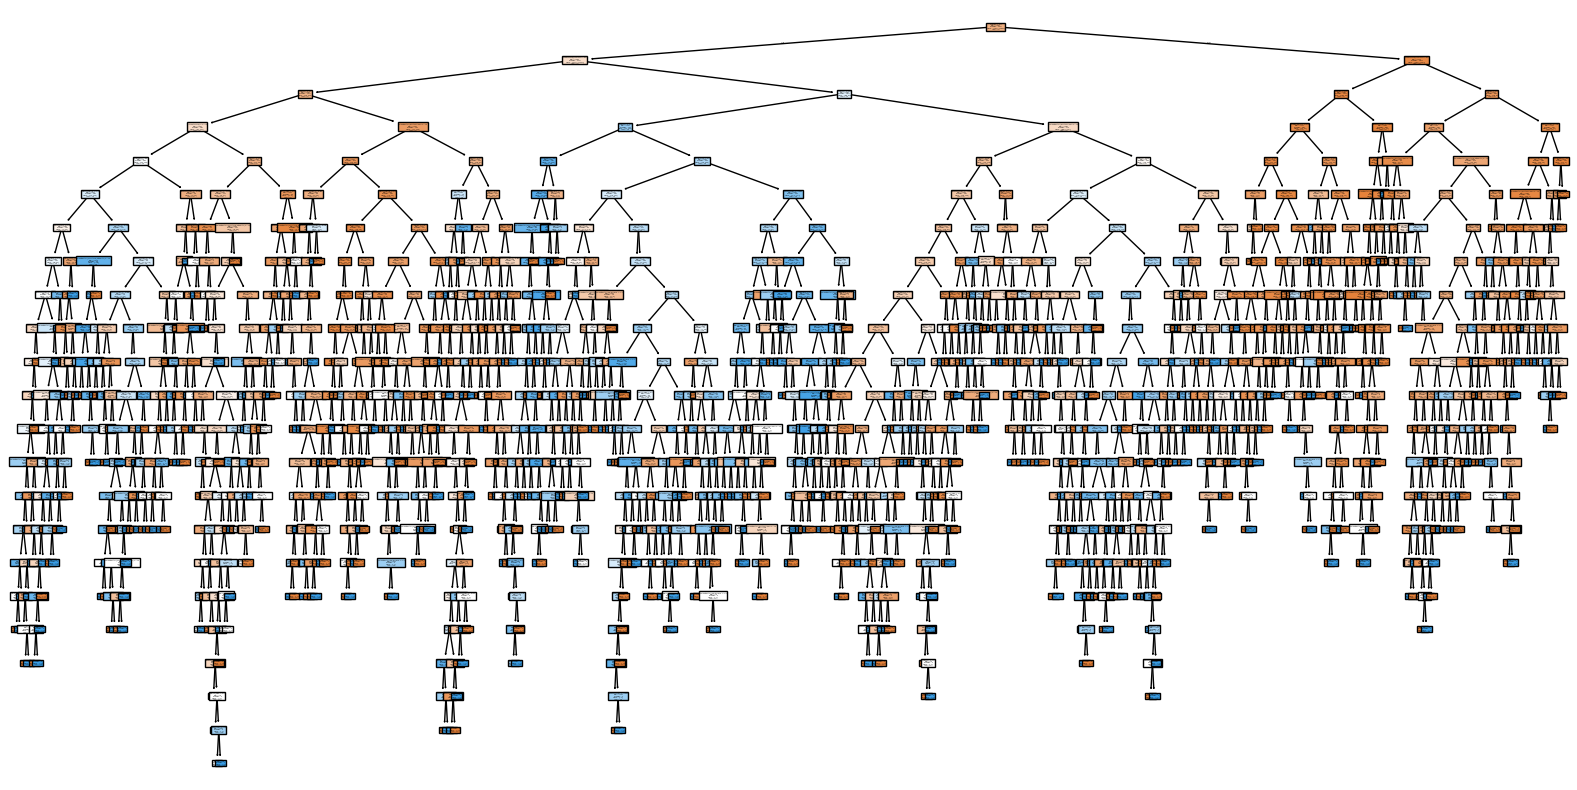

In [66]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X_train.columns, class_names=["No", "Yes"], filled=True)
plt.show()

In [74]:
from sklearn.tree import export_graphviz
import graphviz
%matplotlib inline

dot_data = export_graphviz(
    dtc,
    out_file=None,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True
)

graph = graphviz.Source(dot_data)
graph

In [75]:
graph.render("decision_tree", format="png", cleanup=True)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.589748 to fit


'decision_tree.png'

In [76]:
graph.render("decision_tree", format="pdf", cleanup=True)

'decision_tree.pdf'

### Random Forest

In [84]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]



In [85]:
y_pred

array(['Yes', 'Yes', 'No', ..., 'No', 'Yes', 'No'],
      shape=(1056,), dtype=object)

In [86]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
print("Random Forest\n")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Random Forest

Accuracy:  0.7897727272727273
              precision    recall  f1-score   support

          No       0.82      0.90      0.86       763
         Yes       0.66      0.49      0.57       293

    accuracy                           0.79      1056
   macro avg       0.74      0.70      0.71      1056
weighted avg       0.78      0.79      0.78      1056

ROC-AUC: 0.8292889125465761


### First Tuning RF, then move to other methods

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="roc_auc",   # IMPORTANT
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [88]:
random_search.best_params_

{'n_estimators': 500,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 7}

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    max_features = 'sqrt',
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]
y_test = y_test.map({'No': 0, 'Yes': 1})

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = (y_prob >= t).astype(int)
    print(t, recall_score(y_test, y_pred))


0.1 0.9829351535836177
0.15000000000000002 0.9726962457337884
0.20000000000000004 0.962457337883959
0.25000000000000006 0.931740614334471
0.30000000000000004 0.9078498293515358
0.3500000000000001 0.863481228668942
0.40000000000000013 0.8225255972696246
0.45000000000000007 0.7815699658703071
0.5000000000000001 0.7542662116040956
0.5500000000000002 0.7337883959044369
0.6000000000000002 0.6996587030716723
0.6500000000000001 0.6552901023890785
0.7000000000000002 0.6075085324232082
0.7500000000000002 0.5221843003412969
0.8000000000000002 0.4197952218430034
0.8500000000000002 0.24232081911262798


In [101]:
y_pred = (y_prob >= 0.4).astype(int)

In [102]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
print("Random Forest\n")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Random Forest

Accuracy:  0.6988636363636364
              precision    recall  f1-score   support

           0       0.91      0.65      0.76       763
           1       0.48      0.82      0.60       293

    accuracy                           0.70      1056
   macro avg       0.69      0.74      0.68      1056
weighted avg       0.79      0.70      0.71      1056

ROC-AUC: 0.8330798581135183


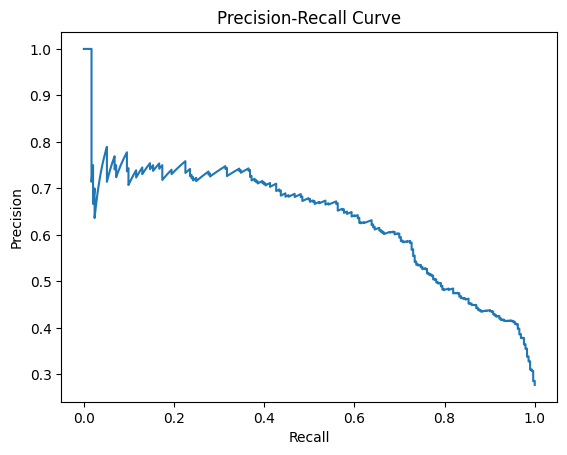

In [105]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### XG Boost

In [115]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [116]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [117]:
y_prob = xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

C:\Users\priya\Desktop\PyCh_Pro\Churn_Analysis_and_Modelling\.venv\lib\site-packages\sklearn\externals\array_api_compat\numpy\_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y_true contains NaN.

In [ ]:
# 6. PRECISION-RECALL CURVE
# =========================

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# =========================
# 7. THRESHOLD TUNING
# =========================

print("\nThreshold Tuning:\n")

best_t = 0.5
best_score = 0

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = (y_prob >= t).astype(int)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    print(f"Threshold: {t:.2f} | Recall: {rec:.3f} | Precision: {prec:.3f}")